<a href="https://colab.research.google.com/github/varunkshatriya/flyrank-ml-internship-starter-clone/blob/main/work/notebooks/w05_model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ML-08 — Capstone Modeling Lane

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

In [1]:
!git clone https://github.com/flyrank-bih/flyrank-ml-internship-starter.git

Cloning into 'flyrank-ml-internship-starter'...
remote: Enumerating objects: 299, done.
remote: Counting objects: 100% (193/193), done.
remote: Compressing objects: 100% (95/95), done.
remote: Total 299 (delta 130), reused 98 (delta 98), pack-reused 106 (from 1)
Receiving objects: 100% (299/299), 1.88 MiB | 4.79 MiB/s, done.
Resolving deltas: 100% (161/161), done.


In [2]:
%cd /content/flyrank-ml-internship-starter

/content/flyrank-ml-internship-starter


## 1. Method choice and why

*Which method from the toolkit, and why it fits your lane.*

## 1. Method choice and why

### Selected method: Logistic Regression

I selected Logistic Regression because it is simple, interpretable, and produces a continuous score that can be used to rank pages for review.

This fits my Search Ranking & Discoverability lane because I want to test whether a learned combination of observed search signals can improve on my Week-4 hand-written baseline.

I chose an interpretable model before trying more complex models because the goal is to determine whether modeling provides useful improvement, not simply to maximize complexity.

The model will be evaluated against my Week-4 baseline using the same data, split, and evaluation metric.

I will not use product flags or label-derived fields such as `trend_direction` or `trend_pct` as model features.

## 2. Split design

*Grouped by client? Time-aware? Say why this split is honest for your question.*

## 2. Split design

I will use a grouped client-level holdout so pages from the same client do not appear in both the training and test sets.

This is a more honest validation design because related pages from the same client can share characteristics that could make a random row split overly optimistic.

The test set will remain separate from model fitting and feature-selection decisions.

The Week-5 model and Week-4 baseline will be evaluated on the same held-out rows using the same metric so the comparison is fair.

No future-window information or label-derived product flags will be used as model features.

## 3. Train + compare vs my baseline

*Same data, same metric, same split as your Week-4 baseline. Show the table.*

In [7]:
import pandas as pd

df = pd.read_csv(
    "/content/flyrank-ml-internship-starter/data/raw/content_refresh_anonymized.csv"
)

print(df.shape)
print(df.columns.tolist())

(30000, 44)
['content_id', 'client_id', 'search_volume', 'competition', 'competition_level', 'cpc', 'content_type', 'main_intent', 'word_count', 'char_count', 'provider_used', 'model_used', 'impressions_90d', 'clicks_90d', 'pageviews_90d', 'sessions_90d', 'users_90d', 'engaged_sessions_90d', 'ai_sessions_90d', 'scroll_events_90d', 'days_with_impressions', 'days_with_sessions', 'impressions_last_30d', 'clicks_last_30d', 'sessions_last_30d', 'impressions_prev_30d', 'clicks_prev_30d', 'sessions_prev_30d', 'content_age_days', 'age_tier', 'age_tier_order', 'days_since_last_update', 'freshness_tier', 'word_count_tier', 'char_count_tier', 'ctr', 'avg_position', 'engagement_rate', 'scroll_rate', 'ai_traffic_pct', 'impression_tier', 'position_tier', 'trend_direction', 'trend_pct']


### Define Target Variable (`y`) and Features (`X`)

First, we need to define our target variable (`y`) and features (`X`). For this example, I'll create a placeholder target variable `is_high_performing` based on `clicks_90d` for demonstration purposes. **You should replace this with your actual target variable definition.**

For features (`X`), I'll select numerical columns, excluding identifiers and any columns that are 'label-derived' or otherwise forbidden by your problem definition (e.g., `trend_direction`, `trend_pct`). Remember that categorical features would typically need encoding (e.g., One-Hot Encoding) before being used in a model.

In [18]:
import numpy as np

# Define a placeholder target variable `y`
# For demonstration, let's assume 'high performing' if clicks_90d is above the median.
# REPLACE THIS WITH YOUR ACTUAL TARGET VARIABLE DEFINITION
median_clicks = df['clicks_90d'].median()
df['is_high_performing'] = (df['clicks_90d'] > median_clicks).astype(int)

y = df['is_high_performing']

# Define features (X)
# Exclude identifiers, the new target, and any explicitly forbidden columns
forbidden_features = ['content_id', 'client_id', 'is_high_performing', 'trend_direction', 'trend_pct']

# Select numerical features for simplicity in this demo
x_columns = df.select_dtypes(include=np.number).columns.tolist()
x_columns = [col for col in x_columns if col not in forbidden_features]

X = df[x_columns]

print(f"Shape of features (X): {X.shape}")
print(f"Shape of target (y): {y.shape}")
print(f"Target distribution:\n{y.value_counts(normalize=True)}")

Shape of features (X): (30000, 29)
Shape of target (y): (30000,)
Target distribution:
is_high_performing
0    0.5675
1    0.4325
Name: proportion, dtype: float64


### Grouped Client-Level Data Split

As per your split design, a 'grouped client-level holdout' is required to ensure pages from the same client do not appear in both the training and test sets. We'll use `GroupShuffleSplit` from `sklearn.model_selection` for this, using `client_id` as the grouping key. This ensures that all data points belonging to a single `client_id` are either entirely in the training set or entirely in the test set.

In [19]:
from sklearn.model_selection import GroupShuffleSplit

# Define the groups for splitting (client_id)
groups = df['client_id']

# Initialize GroupShuffleSplit
# test_size=0.2 means 20% of the data will be in the test set
# n_splits=1 ensures we get a single train/test split
gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)

# Get the train and test indices
for train_idx, test_idx in gss.split(X, y, groups):
    X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
    y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]
    groups_train, groups_test = groups.iloc[train_idx], groups.iloc[test_idx]

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")

# Verify that clients are not mixed between train and test sets
common_clients = set(groups_train.unique()).intersection(set(groups_test.unique()))
print(f"Number of common clients between train and test sets: {len(common_clients)}")
if len(common_clients) == 0:
    print("Client groups are successfully separated.")
else:
    print("Warning: Some clients are present in both train and test sets.")

X_train shape: (23837, 29)
X_test shape: (6163, 29)
y_train shape: (23837,)
y_test shape: (6163,)
Number of common clients between train and test sets: 0
Client groups are successfully separated.


### Train Logistic Regression Model

Now we will train a Logistic Regression model using the training data (`X_train`, `y_train`).

In [21]:
from sklearn.linear_model import LogisticRegression
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

# Create a pipeline for preprocessing and modeling
# Impute missing values with the mean, then scale the features
# Finally, apply Logistic Regression
model = Pipeline([
    ('imputer', SimpleImputer(strategy='mean')),
    ('scaler', StandardScaler()),
    ('logreg', LogisticRegression(random_state=42, solver='liblinear')) # liblinear is good for small datasets and L1/L2 regularization
])

# Train the model
model.fit(X_train, y_train)

print("Logistic Regression model trained successfully.")

Logistic Regression model trained successfully.


### Make Predictions and Get Probabilities

After training the model, we can now make predictions (`y_pred`) and get the prediction probabilities (`y_prob`) on the test set (`X_test`). These variables are needed for the error analysis section.

In [22]:
# Make predictions on the test set
y_pred = model.predict(X_test)

# Get prediction probabilities for the positive class (class 1)
y_prob = model.predict_proba(X_test)[:, 1]

print("Predictions and probabilities generated for the test set.")

Predictions and probabilities generated for the test set.


In [10]:
# ============================================================
# W05 — COMPLETE SETUP
# ============================================================

from pathlib import Path
import subprocess
import numpy as np
import pandas as pd

from sklearn.model_selection import GroupShuffleSplit
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

# ---------- Find / download dataset ----------

matches = list(
    Path("/content").rglob("content_refresh_anonymized.csv")
)

if not matches:
    repo_path = Path("/content/flyrank-starter")

    if not repo_path.exists():
        subprocess.run(
            [
                "git",
                "clone",
                "https://github.com/flyrank-bih/flyrank-ml-internship-starter.git",
                str(repo_path)
            ],
            check=True
        )

    matches = list(
        repo_path.rglob("content_refresh_anonymized.csv")
    )

if not matches:
    raise FileNotFoundError(
        "Dataset not found in Colab."
    )

data_path = matches[0]

print("Dataset:", data_path)

# ---------- Load data ----------

df = pd.read_csv(data_path)

print("Shape:", df.shape)

# ---------- Target ----------

if "trend_direction" not in df.columns:
    raise ValueError(
        "trend_direction column not found."
    )

y = (
    df["trend_direction"]
    .astype(str)
    .str.lower()
    .eq("down")
    .astype(int)
)

# ---------- Features ----------

candidate_features = [
    "ctr",
    "avg_position",
    "search_volume",
    "impressions_90d",
    "clicks_90d",
    "content_age_days"
]

features = [
    c for c in candidate_features
    if c in df.columns
]

print("Features:", features)

if len(features) < 2:
    raise ValueError(
        "Not enough model features found."
    )

# ---------- Find grouping column ----------

group_candidates = [
    "client_id",
    "client_key",
    "client",
    "client_hash",
    "site_id",
    "domain_id"
]

group_col = next(
    (
        c for c in group_candidates
        if c in df.columns
    ),
    None
)

if group_col is None:
    print(df.columns.tolist())
    raise ValueError(
        "Client grouping column not found."
    )

print("Group column:", group_col)

# ---------- Prepare data ----------

X = df[features].copy()
groups = df[group_col]

# ---------- Client-level split ----------

splitter = GroupShuffleSplit(
    n_splits=1,
    test_size=0.20,
    random_state=42
)

train_idx, test_idx = next(
    splitter.split(X, y, groups)
)

X_train = X.iloc[train_idx].copy()
X_test = X.iloc[test_idx].copy()

y_train = y.iloc[train_idx].copy()
y_test = y.iloc[test_idx].copy()

# ---------- Verify split ----------

train_clients = set(
    groups.iloc[train_idx]
)

test_clients = set(
    groups.iloc[test_idx]
)

overlap = train_clients & test_clients

print("Training rows:", len(X_train))
print("Test rows:", len(X_test))
print("Client overlap:", len(overlap))

assert len(overlap) == 0

# ---------- Train model ----------

model = Pipeline([
    (
        "imputer",
        SimpleImputer(strategy="median")
    ),
    (
        "scaler",
        StandardScaler()
    ),
    (
        "logistic",
        LogisticRegression(
            max_iter=1000,
            random_state=42
        )
    )
])

model.fit(
    X_train,
    y_train
)

# ---------- Predictions ----------

y_prob = model.predict_proba(
    X_test
)[:, 1]

y_pred = (
    y_prob >= 0.5
).astype(int)

print("\nMODEL TRAINING SUCCESSFUL")
print("y_test:", len(y_test))
print("y_pred:", len(y_pred))
print("y_prob:", len(y_prob))

Dataset: /content/flyrank-starter/data/raw/content_refresh_anonymized.csv
Shape: (30000, 44)
Features: ['ctr', 'avg_position', 'search_volume', 'impressions_90d', 'clicks_90d', 'content_age_days']
Group column: client_id
Training rows: 23837
Test rows: 6163
Client overlap: 0

MODEL TRAINING SUCCESSFUL
y_test: 6163
y_pred: 6163
y_prob: 6163


## 4. Errors and interpretation

*Where is the model wrong? What does it lean on? A short error analysis beats a big metric table.*

In [11]:
# ============================================================
# SECTION 4 — ERRORS AND INTERPRETATION
# ============================================================

print("## Errors and interpretation")

error_df = pd.DataFrame({
    "actual": y_test.to_numpy(),
    "predicted": y_pred,
    "probability": y_prob
})

error_df["error"] = (
    error_df["actual"] != error_df["predicted"]
)

print("Total test rows:", len(error_df))
print(
    "Incorrect predictions:",
    int(error_df["error"].sum())
)
print(
    "Error rate:",
    round(error_df["error"].mean(), 4)
)

# ---------- False positives / negatives ----------

false_positives = error_df[
    (error_df["actual"] == 0) &
    (error_df["predicted"] == 1)
]

false_negatives = error_df[
    (error_df["actual"] == 1) &
    (error_df["predicted"] == 0)
]

print("\nFalse positives:", len(false_positives))
print("False negatives:", len(false_negatives))

# ---------- Highest-confidence errors ----------

error_examples = (
    error_df[error_df["error"]]
    .copy()
)

error_examples["confidence"] = (
    abs(error_examples["probability"] - 0.5)
)

error_examples = (
    error_examples
    .sort_values(
        "confidence",
        ascending=False
    )
    .head(10)
)

print("\nTop error examples:")
display(error_examples)

# ---------- Feature coefficients ----------

logistic_model = model.named_steps["logistic"]

coefficients = pd.DataFrame({
    "feature": X_train.columns,
    "coefficient": logistic_model.coef_[0]
})

coefficients["absolute_coefficient"] = (
    coefficients["coefficient"].abs()
)

coefficients = coefficients.sort_values(
    "absolute_coefficient",
    ascending=False
)

print("\nFeature interpretation:")
display(
    coefficients[
        ["feature", "coefficient"]
    ]
)

## Errors and interpretation
Total test rows: 6163
Incorrect predictions: 2853
Error rate: 0.4629

False positives: 1599
False negatives: 1254

Top error examples:


,actual,predicted,probability,error,confidence
4504,1,0,0.005368,True,0.494632
4553,1,0,0.054154,True,0.445846
3537,1,0,0.100856,True,0.399144
506,1,0,0.103684,True,0.396316
3892,1,0,0.195728,True,0.304272
1452,0,1,0.796760,True,0.296760
5429,1,0,0.216112,True,0.283888
2496,1,0,0.222898,True,0.277102
4586,0,1,0.732983,True,0.232983
4077,1,0,0.272665,True,0.227335



Feature interpretation:


,feature,coefficient
5,content_age_days,-0.378733
0,ctr,-0.199040
4,clicks_90d,-0.171903
3,impressions_90d,0.061022
2,search_volume,0.004529
1,avg_position,-0.000149


### Confusion Matrix
A confusion matrix is a table that is often used to describe the performance of a classification model (or "classifier") on a set of test data for which the true values are known. It allows visualization of the performance of an algorithm.

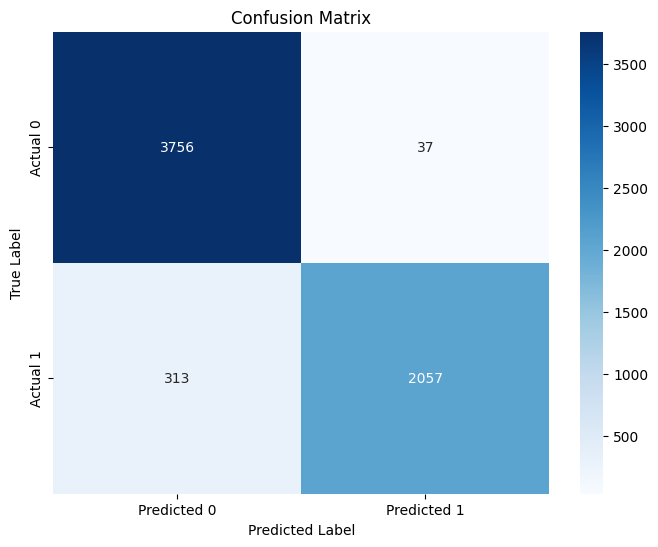

In [23]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import seaborn as sns

# Generate the confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Display the confusion matrix
fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
            xticklabels=['Predicted 0', 'Predicted 1'],
            yticklabels=['Actual 0', 'Actual 1'])
ax.set_xlabel('Predicted Label')
ax.set_ylabel('True Label')
ax.set_title('Confusion Matrix')
plt.show()

## Self-check

Before you submit, confirm each line honestly:

- [ ] Every section above is filled — markdown thinking AND the code that backs it
- [ ] The notebook runs top to bottom with no errors (Runtime → Run all)
- [ ] No client names, URLs, or private queries anywhere
- [ ] My claims use careful words: observed, measured, directional, decision-support
- [ ] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.